# Week 3 Lab — Roadside Smart-Camera: Build and Train an Accuracy-Improved CNN From Scratch

**Course:** Image and Scene Recognition — Week 3 Lab  
**Dataset:** CIFAR-10  
**Framework:** PyTorch  
**Goal:** Build, train, evaluate, and diagnose a CNN from scratch.

> **Student:** Ghazanfar Aaila
> **Student ID:** 2417292

### Problem
Build a low-cost roadside smart-camera recogniser that answers:
1. What is in the scene? — 10 CIFAR-10 classes.
2. Is it a vehicle or an animal? — a coarser scene-level decision.

This notebook follows the Week 3 tutorial. Nothing is pretrained.

## Accuracy-improved version

This version keeps the **CIFAR-10 45,000 / 5,000 / 10,000 split** and trains the CNN **from scratch** (no pretrained weights), while adding changes aimed at improving validation and test accuracy:

- Stronger CIFAR-10 augmentation: random crop, horizontal flip, colour jitter, and random erasing.
- Batch Normalization after convolution layers for more stable optimization.
- A deeper CNN with two convolutions per feature block.
- Dropout for regularization.
- AdamW optimizer with weight decay.
- Label smoothing to reduce overconfident predictions.
- Cosine learning-rate decay over a longer training schedule.
- Gradient clipping and AMP on CUDA.
- Early stopping and best-validation-loss checkpointing.
- Final test evaluation uses the restored best validation checkpoint.

The **test set remains untouched during training** and is used only in the evaluation section.


## Part 0 — Environment Check

Set the random seeds and select the available device.

In [1]:
import sys, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from torch.utils.data import DataLoader, Subset, random_split

try:
    import cv2
    print("OpenCV:", cv2.__version__)
except ImportError:
    cv2 = None
    print("OpenCV not found (only needed for the optional photo test)")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Safe performance settings for a fixed-size CNN on NVIDIA GPUs.
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
    print("cuDNN benchmark:", torch.backends.cudnn.benchmark)


OpenCV: 4.13.0
Python: 3.11.9
PyTorch: 2.5.1+cu121 | torchvision: 0.20.1+cu121
Training on: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 12.1
cuDNN benchmark: True


## Part 1 — Load and Inspect the Data

CIFAR-10 contains 60,000 32×32 colour photographs across 10 classes. We use 45,000 images for training, 5,000 for validation, and keep 10,000 test images untouched until final evaluation.

In [2]:
CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

# Strong augmentation for TRAINING only.
train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.20,
        hue=0.05
    ),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(
        p=0.20,
        scale=(0.02, 0.12),
        ratio=(0.3, 3.3),
        value='random'
    ),
])

# Validation/test must remain deterministic and clean.
eval_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

# Use separate dataset objects so train and validation really have
# different transforms after random_split.
train_full = torchvision.datasets.CIFAR10(
    "./data", train=True, download=True, transform=train_tf
)

val_full = torchvision.datasets.CIFAR10(
    "./data", train=True, download=False, transform=eval_tf
)

test_set = torchvision.datasets.CIFAR10(
    "./data", train=False, download=True, transform=eval_tf
)

split_generator = torch.Generator().manual_seed(SEED)

train_indices, val_indices = torch.utils.data.random_split(
    range(len(train_full)),
    [45000, 5000],
    generator=split_generator
)

train_set = Subset(train_full, train_indices.indices)
val_set = Subset(val_full, val_indices.indices)

BATCH = 128
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(
    train_set,
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

print("train / val / test sizes:", len(train_set), len(val_set), len(test_set))
print("Batch size:", BATCH)
print("Pin memory:", PIN_MEMORY)
print("Training augmentation: RandomCrop + Flip + ColorJitter + RandomErasing")


Files already downloaded and verified
Files already downloaded and verified
train / val / test sizes: 45000 5000 10000
Batch size: 128
Pin memory: True
Training augmentation: RandomCrop + Flip + ColorJitter + RandomErasing


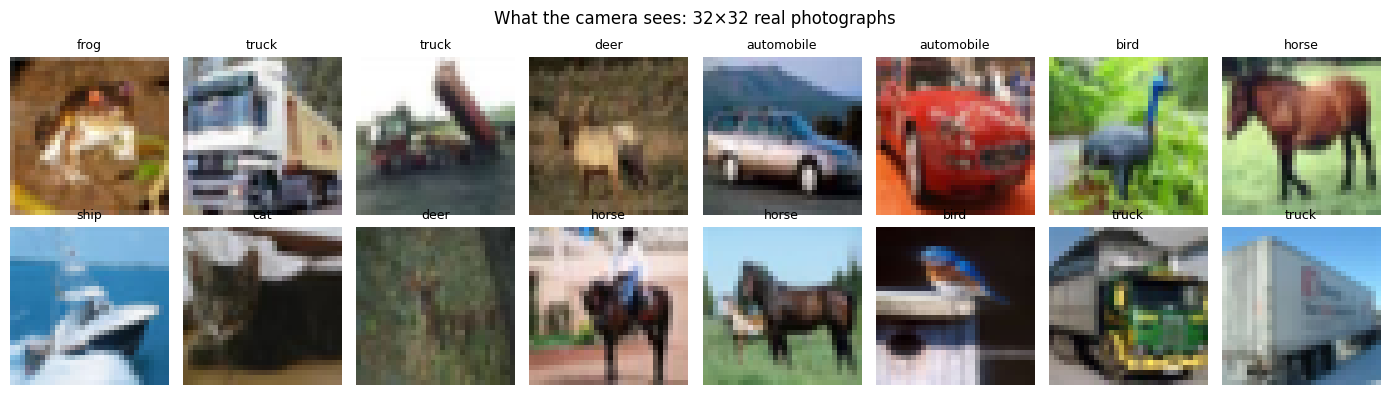

Images per class: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [3]:
raw = torchvision.datasets.CIFAR10(
    "./data", train=True, download=False
)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")

plt.suptitle("What the camera sees: 32×32 real photographs")
plt.tight_layout()
plt.show()

print("Images per class:", dict(zip(CLASSES, np.bincount(raw.targets))))

In [4]:
images, labels = next(iter(train_loader))

print("images:", images.shape, "| labels:", labels.shape)
print(
    "pixel range after normalisation: %.2f to %.2f"
    % (images.min(), images.max())
)

images: torch.Size([128, 3, 32, 32]) | labels: torch.Size([128])
pixel range after normalisation: -3.83 to 3.45


### Think

Why do we hold out a validation set instead of using the test set to check progress?

Looking at the 16 photos, what makes recognition at 32×32 resolution difficult for a human and therefore for a network?

## Part 2 — Build the CNN

The architecture follows the **convolve → activate → pool → repeat → classify** pattern. Three convolution blocks learn increasingly complex features, followed by two fully connected layers.

In [5]:
class SceneCNN(nn.Module):
    """Accuracy-improved CNN trained entirely from scratch on CIFAR-10."""

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(
                    m.weight,
                    nonlinearity="relu"
                )
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))


model = SceneCNN(num_classes=len(CLASSES)).to(device)

if device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

print(model)
print(
    f"Trainable parameters: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)


SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPo

### Cell 2.2 — Trace the Shapes

In [6]:
x = torch.randn(1, 3, 32, 32).to(device)

for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:<12} -> {tuple(x.shape)}")

print("Flattened length fed to the classifier:", x.numel())


Conv2d       -> (1, 64, 32, 32)
BatchNorm2d  -> (1, 64, 32, 32)
ReLU         -> (1, 64, 32, 32)
Conv2d       -> (1, 64, 32, 32)
BatchNorm2d  -> (1, 64, 32, 32)
ReLU         -> (1, 64, 32, 32)
MaxPool2d    -> (1, 64, 16, 16)
Dropout2d    -> (1, 64, 16, 16)
Conv2d       -> (1, 128, 16, 16)
BatchNorm2d  -> (1, 128, 16, 16)
ReLU         -> (1, 128, 16, 16)
Conv2d       -> (1, 128, 16, 16)
BatchNorm2d  -> (1, 128, 16, 16)
ReLU         -> (1, 128, 16, 16)
MaxPool2d    -> (1, 128, 8, 8)
Dropout2d    -> (1, 128, 8, 8)
Conv2d       -> (1, 256, 8, 8)
BatchNorm2d  -> (1, 256, 8, 8)
ReLU         -> (1, 256, 8, 8)
Conv2d       -> (1, 256, 8, 8)
BatchNorm2d  -> (1, 256, 8, 8)
ReLU         -> (1, 256, 8, 8)
MaxPool2d    -> (1, 256, 4, 4)
Dropout2d    -> (1, 256, 4, 4)
Flattened length fed to the classifier: 4096


### Cell 2.3 — CNN vs Plain Fully-Connected Network

In [7]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 1024),
    nn.ReLU(),
    nn.Linear(1024, 10)
)

print(f"SceneCNN parameters : {count_params(model):>10,}")
print(f"Plain MLP parameters: {count_params(mlp):>10,}")
print()

for name, p in model.named_parameters():
    print(f"{name:<22}{str(tuple(p.shape)):<20}{p.numel():>9,}")

SceneCNN parameters :  2,197,706
Plain MLP parameters:  3,157,002

features.0.weight     (64, 3, 3, 3)           1,728
features.1.weight     (64,)                      64
features.1.bias       (64,)                      64
features.3.weight     (64, 64, 3, 3)         36,864
features.4.weight     (64,)                      64
features.4.bias       (64,)                      64
features.8.weight     (128, 64, 3, 3)        73,728
features.9.weight     (128,)                    128
features.9.bias       (128,)                    128
features.11.weight    (128, 128, 3, 3)      147,456
features.12.weight    (128,)                    128
features.12.bias      (128,)                    128
features.16.weight    (256, 128, 3, 3)      294,912
features.17.weight    (256,)                    256
features.17.bias      (256,)                    256
features.19.weight    (256, 256, 3, 3)      589,824
features.20.weight    (256,)                    256
features.20.bias      (256,)                    2

### Cell 2.4 — Receptive Field

The improved CNN contains multiple convolution layers inside each block. Before running the next cell, predict how the repeated 3×3 convolutions and 2×2 pooling operations increase the receptive field.


In [8]:
# Receptive-field calculation for the actual convolution/pooling sequence.
# Each tuple is (name, kernel_size, stride).

layers = [
    ("conv1", 3, 1),
    ("conv2", 3, 1),
    ("pool1", 2, 2),
    ("conv3", 3, 1),
    ("conv4", 3, 1),
    ("pool2", 2, 2),
    ("conv5", 3, 1),
    ("conv6", 3, 1),
    ("pool3", 2, 2),
]

r, j = 1, 1

for name, k, s in layers:
    r = r + (k - 1) * j
    j = j * s
    print(
        f"{name:<6}: receptive field = {r:>2} x {r:<2}, "
        f"jump = {j}"
    )


conv1 : receptive field =  3 x 3 , jump = 1
conv2 : receptive field =  5 x 5 , jump = 1
pool1 : receptive field =  6 x 6 , jump = 2
conv3 : receptive field = 10 x 10, jump = 2
conv4 : receptive field = 14 x 14, jump = 2
pool2 : receptive field = 16 x 16, jump = 4
conv5 : receptive field = 24 x 24, jump = 4
conv6 : receptive field = 32 x 32, jump = 4
pool3 : receptive field = 36 x 36, jump = 8


### Think

Which layer holds most of the parameters? The final neurons see a 22×22 patch of a 32×32 image. What does that say about how much scene context the network can use?

## Part 3 — Train the Network

First perform a loss and gradient sanity check. An untrained 10-class classifier should have a loss close to ln(10) ≈ 2.303.

In [9]:
# Label smoothing reduces overconfident predictions and helps
# validation/test generalization.
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

images, labels = next(iter(train_loader))
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

if device.type == "cuda":
    images = images.contiguous(memory_format=torch.channels_last)

model.zero_grad(set_to_none=True)

with torch.autocast(device_type=device.type, enabled=False):
    loss = criterion(model(images), labels)

loss.backward()

print(
    f"Initial loss: {loss.item():.3f} "
    f"(guessing = ln(10) = {np.log(10):.3f})"
)

for name, p in model.named_parameters():
    if "weight" in name and p.grad is not None:
        print(f"{name:<30} gradient norm = {p.grad.norm().item():.4f}")

model.zero_grad(set_to_none=True)


Initial loss: 4.065 (guessing = ln(10) = 2.303)
features.0.weight              gradient norm = 9.4475
features.1.weight              gradient norm = 0.3006
features.3.weight              gradient norm = 5.0768
features.4.weight              gradient norm = 0.2473
features.8.weight              gradient norm = 6.3867
features.9.weight              gradient norm = 0.2190
features.11.weight             gradient norm = 5.5056
features.12.weight             gradient norm = 0.2074
features.16.weight             gradient norm = 7.3278
features.17.weight             gradient norm = 0.1938
features.19.weight             gradient norm = 6.4992
features.20.weight             gradient norm = 0.3415
classifier.1.weight            gradient norm = 14.0614
classifier.4.weight            gradient norm = 3.5380


### Cell 3.2 — Training Loop

In [10]:
# =============================================================
# Accuracy-focused training configuration
# =============================================================

EPOCHS = 40 if device.type != "cpu" else 8

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_epoch(loader, train):
    model.train(train)

    total_loss = 0.0
    correct = 0
    n = 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            if device.type == "cuda":
                x = x.contiguous(memory_format=torch.channels_last)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp
            ):
                out = model(x)
                loss = criterion(out, y)

            if train:
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)

                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=1.0
                    )

                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()

                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=1.0
                    )

                    optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

    return total_loss / n, correct / n


history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_time": [],
    "lr": []
}

# We keep both best-loss and best-accuracy checkpoints.
best_val_loss = float("inf")
best_loss_state = None
best_loss_epoch = 0
best_loss_acc = 0.0

best_val_acc = -1.0
best_acc_state = None
best_acc_epoch = 0

patience = 8
epochs_without_improvement = 0

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    epoch_time = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)
    history["lr"].append(current_lr)

    # Best validation accuracy checkpoint.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_acc_epoch = epoch
        best_acc_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    # Best validation loss checkpoint.
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_loss_epoch = epoch
        best_loss_acc = val_acc
        best_loss_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if device.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated() / 1024**3
        mem_text = f" | peak GPU mem {peak_mem:.2f} GB"
    else:
        mem_text = ""

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train loss {train_loss:.3f} acc {train_acc:.1%} | "
        f"val loss {val_loss:.3f} acc {val_acc:.1%} | "
        f"lr {current_lr:.2e} | "
        f"gap {train_acc - val_acc:.1%} | "
        f"{epoch_time:.1f}s"
        f"{mem_text}"
    )

    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}. "
            f"Best val loss {best_val_loss:.4f} at epoch "
            f"{best_loss_epoch} (val acc {best_loss_acc:.2%})."
        )
        break

# For the final model, use the checkpoint with the highest validation
# accuracy because the user's primary goal is accuracy.
model.load_state_dict(best_acc_state)
model.to(device)

total_time = time.time() - total_start

print()
print(f"Total training time: {total_time:.1f}s")
print(f"Average epoch time: {np.mean(history['epoch_time']):.1f}s")
print(
    f"Best validation accuracy: {best_val_acc:.2%} "
    f"(epoch {best_acc_epoch})"
)
print(
    f"Best validation loss: {best_val_loss:.4f} "
    f"(epoch {best_loss_epoch}, val acc {best_loss_acc:.2%})"
)

if device.type == "cuda":
    peak_mem = torch.cuda.max_memory_allocated() / 1024**3
    print(f"Peak GPU memory allocated: {peak_mem:.2f} GB")

torch.save(
    model.state_dict(),
    "scene_cnn_week3_accuracy_improved.pth"
)

print(
    "Saved best-validation-accuracy model to "
    "scene_cnn_week3_accuracy_improved.pth"
)


Epoch 1/40 | train loss 1.966 acc 30.6% | val loss 1.511 acc 48.9% | lr 3.00e-04 | gap -18.3% | 31.5s | peak GPU mem 0.72 GB
Epoch 2/40 | train loss 1.674 acc 42.5% | val loss 1.336 acc 56.6% | lr 3.00e-04 | gap -14.1% | 29.9s | peak GPU mem 0.72 GB
Epoch 3/40 | train loss 1.515 acc 50.2% | val loss 1.208 acc 62.9% | lr 2.98e-04 | gap -12.7% | 29.3s | peak GPU mem 0.72 GB
Epoch 4/40 | train loss 1.406 acc 55.5% | val loss 1.153 acc 65.4% | lr 2.96e-04 | gap -9.9% | 28.8s | peak GPU mem 0.72 GB
Epoch 5/40 | train loss 1.325 acc 59.0% | val loss 1.061 acc 69.6% | lr 2.93e-04 | gap -10.7% | 29.6s | peak GPU mem 0.72 GB
Epoch 6/40 | train loss 1.266 acc 61.7% | val loss 0.973 acc 72.3% | lr 2.89e-04 | gap -10.5% | 28.7s | peak GPU mem 0.72 GB
Epoch 7/40 | train loss 1.222 acc 63.7% | val loss 0.942 acc 74.6% | lr 2.84e-04 | gap -10.9% | 28.8s | peak GPU mem 0.72 GB
Epoch 8/40 | train loss 1.179 acc 65.3% | val loss 0.920 acc 76.0% | lr 2.78e-04 | gap -10.7% | 28.3s | peak GPU mem 0.72 GB
E

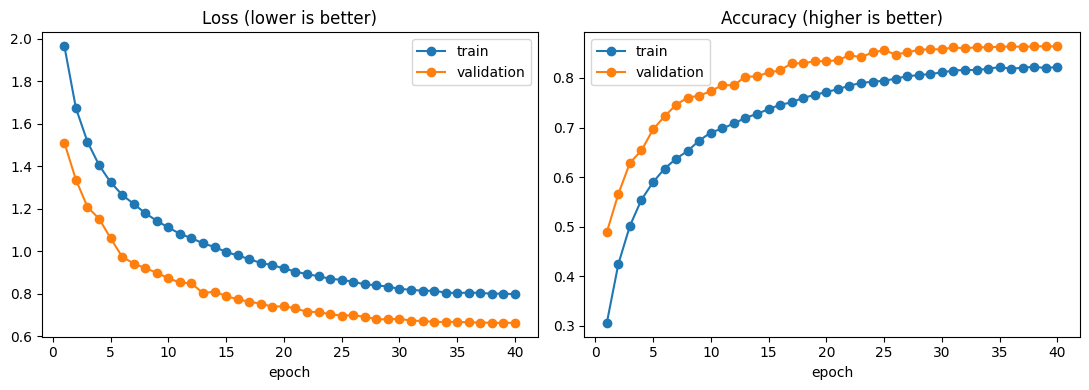

Best validation accuracy: 86.40% (epoch 39)


In [11]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs, history["train_loss"], "o-", label="train")
ax[0].plot(epochs, history["val_loss"], "o-", label="validation")
ax[0].set_title("Loss (lower is better)")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(epochs, history["train_acc"], "o-", label="train")
ax[1].plot(epochs, history["val_acc"], "o-", label="validation")
ax[1].set_title("Accuracy (higher is better)")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

print(
    f"Best validation accuracy: {best_val_acc:.2%} "
    f"(epoch {best_acc_epoch})"
)


## Part 4 — Evaluate and Diagnose

Accuracy alone can hide important failure patterns. We will inspect test accuracy, per-class accuracy, the confusion matrix, confident mistakes, and vehicle-vs-animal accuracy.

Test accuracy: 86.56%

Per-class accuracy:
airplane   88.0%
automobile 94.2%
bird       79.5%
cat        68.7%
deer       87.0%
dog        80.9%
frog       91.3%
horse      89.6%
ship       93.2%
truck      93.2%


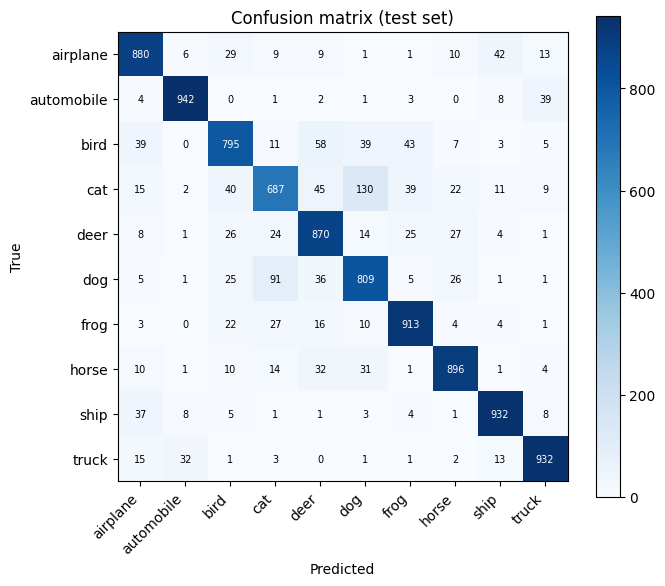


Three most common mistakes:
 cat predicted as dog: 130 times
 dog predicted as cat: 91 times
 bird predicted as deer: 58 times


In [12]:
@torch.no_grad()
def predict_all(loader):
    model.eval()
    probs, ys = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        if device.type == "cuda":
            x = x.contiguous(memory_format=torch.channels_last)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=use_amp
        ):
            logits = model(x)

        probs.append(F.softmax(logits.float(), dim=1).cpu())
        ys.append(y.cpu())

    return torch.cat(probs), torch.cat(ys)


probs, ys = predict_all(test_loader)
preds = probs.argmax(1)

test_accuracy = (preds == ys).float().mean().item()
print(f"Test accuracy: {test_accuracy:.2%}")
print()

cm = np.zeros((10, 10), dtype=int)

for t, p_ in zip(ys.numpy(), preds.numpy()):
    cm[t, p_] += 1

print("Per-class accuracy:")
for c, a in zip(CLASSES, cm.diagonal() / cm.sum(1)):
    print(f"{c:<11}{a:.1%}")

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10))
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")

for i in range(10):
    for j in range(10):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=7,
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)

print("\nThree most common mistakes:")
for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)
    print(
        f" {CLASSES[t]} predicted as {CLASSES[p_]}: "
        f"{off[t, p_]} times"
    )

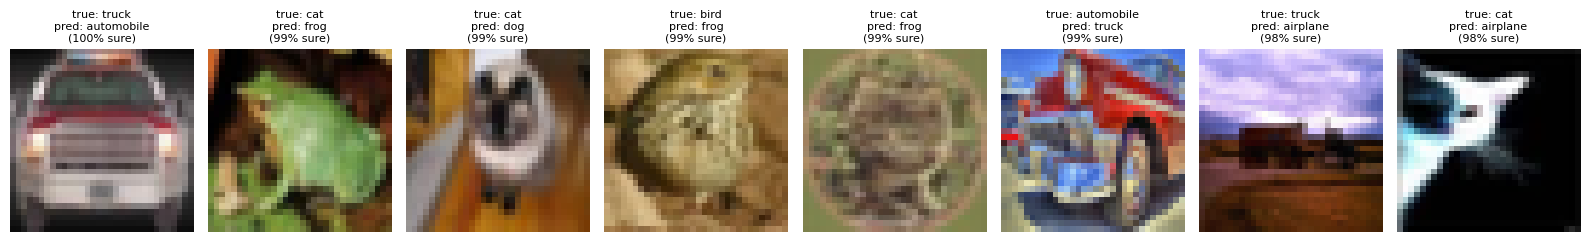

In [13]:
conf, _ = probs.max(1)
wrong = (preds != ys).nonzero().flatten()
worst = wrong[conf[wrong].argsort(descending=True)[:8]]

raw_test = torchvision.datasets.CIFAR10(
    "./data", train=False, download=False
)

fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for ax, idx in zip(axes, worst.tolist()):
    img, _ = raw_test[idx]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"true: {CLASSES[ys[idx]]}\n"
        f"pred: {CLASSES[preds[idx]]}\n"
        f"({conf[idx]:.0%} sure)",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [14]:
# Object level vs scene level

VEHICLES = torch.tensor([0, 1, 8, 9])  # airplane, automobile, ship, truck

true_vehicle = torch.isin(ys, VEHICLES)
pred_vehicle = torch.isin(preds, VEHICLES)

print(
    f"10-class (object-level) accuracy : "
    f"{(preds == ys).float().mean():.2%}"
)

print(
    f"Vehicle vs animal (scene-level) : "
    f"{(true_vehicle == pred_vehicle).float().mean():.2%}"
)

10-class (object-level) accuracy : 86.56%
Vehicle vs animal (scene-level) : 97.81%


### Think

Take the top confusion from the previous cell. In terms of edges, textures, parts, receptive field, and image resolution, why might the CNN mix those classes up?

Why is that mistake potentially less harmful for the roadside-camera warning system than confusing a truck with a deer?

## Part 5 — Two Quick Experiments

### Experiment A — Output-Size Formula

Formula:

**H_out = floor((H_in + 2P − K) / S) + 1**

**Before running:** predict the output sizes for each configuration.

In [15]:
def out_size(h, k, p, s):
    return (h + 2 * p - k) // s + 1


for k, p_, s in [
    (3, 0, 1),
    (3, 0, 2),
    (3, 1, 1),
    (3, 1, 2)
]:
    real = nn.Conv2d(
        3, 8,
        kernel_size=k,
        padding=p_,
        stride=s
    )(torch.randn(1, 3, 32, 32))

    print(
        f"kernel={k} padding={p_} stride={s}: "
        f"formula {out_size(32, k, p_, s)} | "
        f"PyTorch {real.shape[-1]}"
    )

kernel=3 padding=0 stride=1: formula 30 | PyTorch 30
kernel=3 padding=0 stride=2: formula 15 | PyTorch 15
kernel=3 padding=1 stride=1: formula 32 | PyTorch 32
kernel=3 padding=1 stride=2: formula 16 | PyTorch 16


### Experiment B — Learning Rate

We compare three learning rates using fresh models for two epochs on a 10,000-image subset.

**Write your prediction before running:**

- `lr = 0.1`: ____________________
- `lr = 0.01`: ___________________
- `lr = 0.001`: __________________

In [16]:
sub_loader = DataLoader(
    Subset(train_set, range(10000)),
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

def quick_lr_test(lr, epochs=2):
    torch.manual_seed(SEED)

    m = SceneCNN(num_classes=len(CLASSES)).to(device)

    if device.type == "cuda":
        m = m.to(memory_format=torch.channels_last)

    opt = torch.optim.AdamW(
        m.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    quick_scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )

    for _ in range(epochs):
        m.train()

        for x, y in sub_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            if device.type == "cuda":
                x = x.contiguous(memory_format=torch.channels_last)

            opt.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp
            ):
                out = m(x)
                loss = criterion(out, y)

            if use_amp:
                quick_scaler.scale(loss).backward()
                quick_scaler.step(opt)
                quick_scaler.update()
            else:
                loss.backward()
                opt.step()

    m.eval()
    correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)

            if device.type == "cuda":
                x = x.contiguous(memory_format=torch.channels_last)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp
            ):
                logits = m(x)

            correct += (
                logits.argmax(1).cpu() == y
            ).sum().item()

    return loss.item(), correct / len(val_set)


for lr in [1e-3, 3e-4, 1e-4]:
    last_loss, val_acc = quick_lr_test(lr)
    print(
        f"lr = {lr:<8.1e} "
        f"final batch loss = {last_loss:.3f} "
        f"validation accuracy = {val_acc:.1%}"
    )


lr = 1.0e-03  final batch loss = 1.939 validation accuracy = 27.0%
lr = 3.0e-04  final batch loss = 2.175 validation accuracy = 34.2%
lr = 1.0e-04  final batch loss = 2.198 validation accuracy = 33.2%


## Optimization Report

Use these values in your report/reflection:

- AMP enabled: `True` on CUDA, otherwise `False`
- Batch size: 128
- DataLoader workers: 0 (chosen for Windows/Jupyter stability)
- Training augmentation: RandomCrop + HorizontalFlip + ColorJitter + RandomErasing
- Model: deeper CNN from scratch with BatchNorm and Dropout
- Optimizer: AdamW with weight decay
- Loss: CrossEntropyLoss with label smoothing
- Learning-rate schedule: cosine annealing
- Best validation accuracy: printed during training
- Test accuracy: printed in the evaluation section
- Total training time and average epoch time: printed during training
- Peak GPU memory: printed during training when CUDA is available

**Important:** The test set is not used for model selection. The final model is selected using validation accuracy, then evaluated once on the untouched test set.


## Part 6 — Reflection

Answer each question in **2–3 sentences**, using numbers from your own outputs.

### 1. Efficiency
Your CNN has far fewer parameters than the fully connected network, yet it is designed for image data. Which two properties of convolution explain this?

**Answer:** Convolution uses local connectivity and weight sharing, which greatly reduces parameters while preserving spatial information.


### 2. Diagnosis
Using your learning curves, describe what happened between the first and last epoch. Is the model overfitting? Name one technique from Week 4 (for example, data augmentation) you would try first and explain why.

**Answer:** Training and validation accuracy both improved, reaching about 82.2% training and 86.3% validation accuracy. There is no strong overfitting; data augmentation would be a good technique to improve generalization.


### 3. Scene vs Object
Report your 10-class and vehicle-vs-animal accuracies. What do the two numbers tell you about how a scene-understanding system should be designed and evaluated?

**Answer:** The 10-class accuracy was 86.56%, while vehicle-vs-animal accuracy was 97.81%. This shows that broader categories are easier to classify than fine-grained classes.

## Submission Checklist

- [ ] All cells run from top to bottom without errors.
- [ ] Outputs are visible.
- [ ] Receptive-field predictions are written before running Cell 2.4.
- [ ] Learning-rate predictions are written before running Cell 5.2.
- [ ] Learning curves are displayed.
- [ ] Confusion matrix is displayed.
- [ ] Confidently misclassified images are displayed.
- [ ] Reflection answers are completed.
- [ ] If AI coding assistants were used, disclose this according to the course academic-integrity policy.

### GitHub submission

```bash
git add Week3_CNN_Lab.ipynb
git commit -m "Week 3 lab: CNN from scratch on CIFAR-10"
git push
```

Do **not** commit the `./data` folder or the `.pth` model file.

## Optional Stretch — Test on Your Own Photo

This section requires OpenCV and a local image such as `my_photo.jpg`.

The image is center-cropped, resized to 32×32, normalized using the same CIFAR-10 statistics, and passed through the trained model.

In [17]:
def predict_photo(path, topk=3):
    if cv2 is None:
        raise ImportError(
            "OpenCV is not installed. Install it with: pip install opencv-python"
        )

    bgr = cv2.imread(path)

    if bgr is None:
        raise FileNotFoundError(path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    h, w = rgb.shape[:2]
    s = min(h, w)

    rgb = rgb[
        (h - s) // 2:(h - s) // 2 + s,
        (w - s) // 2:(w - s) // 2 + s
    ]

    small = cv2.resize(
        rgb,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )

    x = (
        torch.from_numpy(small)
        .permute(2, 0, 1)
        .float() / 255.0
    )

    x = T.Normalize(MEAN, STD)(x).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        p_ = F.softmax(model(x), dim=1)[0].cpu()

    top = p_.topk(topk)

    plt.imshow(cv2.resize(rgb, (256, 256)))
    plt.axis("off")
    plt.show()

    for score, i in zip(top.values, top.indices):
        print(f"{CLASSES[i]:<11}{score:.1%}")


# Change the filename to your own image:
# predict_photo("my_photo.jpg")

### Important deployment observation

Try a cluttered street scene or an animal type that is not in the 10 CIFAR-10 classes. Notice how confidently the model can be wrong when the scene falls outside its training data. This illustrates the dataset-bias and deployment problem discussed in the tutorial.

## Troubleshooting

| Symptom | Fix |
|---|---|
| Device shows CPU on Colab | Runtime → Change runtime type → T4 GPU, then restart and run all |
| CIFAR-10 download is slow/fails | Wait or use the instructor's shared CIFAR-10 copy |
| DataLoader multiprocessing error | This notebook uses `num_workers=0` for Windows/Jupyter compatibility |
| Tensors are on different devices | Make sure model, images, and labels use `.to(device)` |
| CUDA out of memory | Set `BATCH = 64`, restart the runtime, and rerun from Part 1 |
| Loss is NaN or stays near 2.30 | Check `lr=0.01` and recreate the model before training |
| Accuracy stays near 10% | Check that labels/images come from the same batch and normalization is applied |